In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.pyplot as plt

windows = True

if windows:
    workspace_path = "P:/workspaces/lg-ukbiobank/projects/"
else:
    workspace_path = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/"


color_list_comps = ['#80BBB4', '#00786A', '#00483F', '#F7B682', '#ED6B06', '#8E4114', "#AFD199", "#3A6128", "#F7D27F", "#EEA300", "#8E6214"]

In [15]:
def read_sumstats_REGENIE(fn, drop_cols = None):
    """
    Reads sumstats
    
    Converts regenie output to MRP format (PLINK-like)
    - add necessary column
    - change column names
    
    """
    #load data
    data = pd.read_csv(fn, sep="\t")

    # remove lines without chromosome number
    data.loc[data["CHROM"] == "X" , "CHROM"] = 23
    data.loc[data["CHROM"] == "XY" , "CHROM"] = 23

    for col in data.columns:
        data = data[data[col] != col]

    # convert dtype
    for col in ["CHROM", "GENPOS", "N"]:
        data[col] = data[col].round(0).astype("int64")
    for col in ["A1FREQ", "INFO",  "BETA", "SE", "CHISQ", "LOG10P"]:
        data[col] = data[col].astype("float64")

    #get non-logP for FUMA
    data["P"] = np.power(10, -data["LOG10P"])
    
    if drop_cols:
        data.drop(drop_cols, axis=1, inplace=True)
    
    #use unique ID
    return data.set_index("ID")

def plot_bars(df, eff_col, std_err_col, title, y_label, ax, color, bar_w=0.6, font="Arial"):
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Check if we need x-axis line (if any value in eff_col is negative)
    if (df[eff_col] < 0).any():
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # Create bars without alpha differences (all bars have same alpha)
    if len(color) == 1:
        color = color * len(df)
    for idx, (value, err) in enumerate(zip(df[eff_col], df[std_err_col])):
        # Set capsize=0 to remove error bar tails
        ax.bar(idx, value, yerr=err, alpha=0.8, capsize=0, color=color[idx], width=bar_w, linestyle="")
    
    # Set title and y-label with specified font
    if title:
        ax.set_title(title, fontname=font)
    ax.set_ylabel(y_label, fontname=font)
    
    # Set x-tick labels with specified font
    ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)
    
    # Apply font to y-tick labels as well
    for label in ax.get_yticklabels():
        label.set_fontname(font)

In [9]:
in_path = r"P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest"
#in_path = os.path.join(workspace_path, "CONGRADS_rest", "to_laptop", "gwas")

#nms = ["CONGRADS_gwas_g0_pmaps_34k_lstg_melodic_ic0.regenie", "CONGRADS_gwas_g0_pmaps_34k_lstg_melodic_ic1.regenie", "CONGRADS_gwas_g0_pmaps_34k_lstg_melodic_ic2.regenie", "CONGRADS_gwas_g0_pmaps_34k_lifg_melodic_ic0.regenie", "CONGRADS_gwas_g0_pmaps_34k_lifg_melodic_ic1.regenie", "CONGRADS_gwas_g0_pmaps_34k_lifg_melodic_ic2.regenie", "CONGRADS_gwas_g0_pmaps_multiphen_34k.regenie"]
nms = []

for g in ["g1", "g2"]:
    for roi in ["lifg", "lstg"]:
        for i in range(3):
            if not (g == "g2" and roi == "lifg" and i == 2):
                nms.append(f"CONGRADS_gwas_cmaps_65k_melodic_{g}_cmap_{roi}_oic_{i}.regenie")

#snps = ["rs2346843", "rs35124509", "rs7080472", "rs801597", "rs6226", "rs56093896"]
snps = ["rs13415305", "rs3891783", "rs71481917"]

b_df = pd.DataFrame()

for nm in nms:
    fn = os.path.join(in_path, nm)
    print(fn)
        #load data
    data = read_sumstats_REGENIE(fn)

        #append data to b_df
    b_df = pd.concat([b_df, data.loc[snps, :]])
    del data

P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g1_cmap_lifg_oic_0.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g1_cmap_lifg_oic_1.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g1_cmap_lifg_oic_2.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g1_cmap_lstg_oic_0.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g1_cmap_lstg_oic_1.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g1_cmap_lstg_oic_2.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g2_cmap_lifg_oic_0.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g2_cmap_lifg_oic_1.regenie
P:\workspaces\lg-ukbiobank\projects\CONGRADS_rest\CONGRADS_gwas_cmaps_65k_melodic_g2_cmap_lstg_oic_0.regenie
P:\workspaces\lg-uk

In [10]:
b_df.to_csv(os.path.join(in_path, "results", "lead_snps_all_betas_cmaps.csv"))

C:\Users\jitame\AppData\Local\Temp\ipykernel_15448\2599698149.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)
C:\Users\jitame\AppData\Local\Temp\ipykernel_15448\2599698149.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)
C:\Users\jitame\AppData\Local\Temp\ipykernel_15448\2599698149.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)


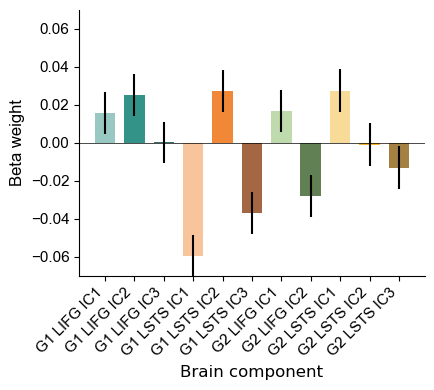

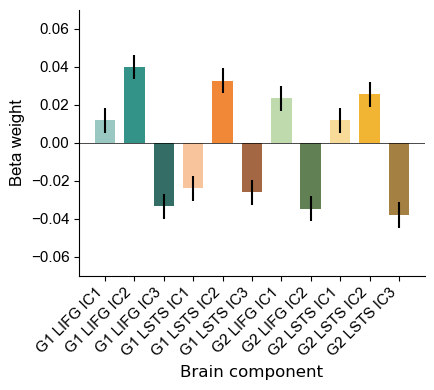

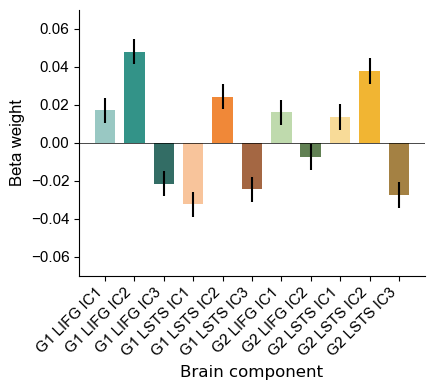

In [17]:
#b_df = pd.read_csv(os.path.join(workspace_path, "CONGRADS_rest", "lead_snps_all_betas.csv"), index_col=0)
snps = ["rs13415305", "rs3891783", "rs71481917"]
genes = ["NRXN1", "PLCE1", "INPP5A"]
for snp, gene in zip(snps, genes):
    in_df = b_df.loc[[snp], :]

    fig, ax = plt.subplots(figsize=(17.8/4, 4))
    plot_bars(df=in_df, eff_col='BETA', std_err_col='SE',
                      title='', y_label='Beta weight', ax=ax, color=color_list_comps, bar_w=0.7)
#switch of legend
    ax.set_xlabel('Brain component', fontsize=12)
    ax.set_ylabel('Beta weight', fontsize=12)
    ax.set_ylim(-0.07, 0.07)

    #change font size ticks and axis labels
    xticks=["G1 LIFG IC1", "G1 LIFG IC2", "G1 LIFG IC3", "G1 LSTS IC1", "G1 LSTS IC2", "G1 LSTS IC3", "G2 LIFG IC1", "G2 LIFG IC2", "G2 LSTS IC1", "G2 LSTS IC2", "G2 LSTS IC3"]
    ax.set_xticks(range(len(xticks)))
    ax.set_xticklabels(xticks, rotation=45, ha='right')

    for label in ax.get_xticklabels():
        label.set_fontsize(11)

    for label in ax.get_yticklabels():
        label.set_fontsize(11)

    plt.tight_layout()
    plt.savefig(os.path.join(in_path, "results", f"Beta_{gene}_{snp}.png"), dpi=400)

# OLD

C:\Users\jitame\AppData\Local\Temp\ipykernel_14852\1487825920.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)


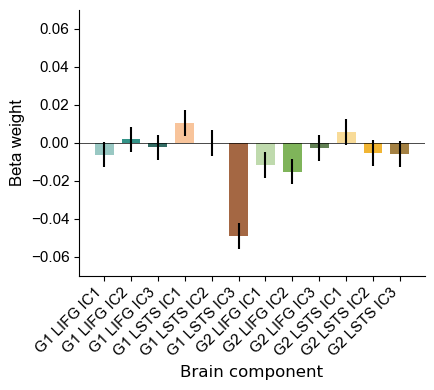

In [ ]:
#b_df = pd.read_csv(os.path.join(workspace_path, "CONGRADS_rest", "lead_snps_all_betas.csv"), index_col=0)
in_df = b_df.loc[["rs2346843"], :]

fig, ax = plt.subplots(figsize=(17.8/4, 4))
plot_bars(df=in_df, eff_col='BETA', std_err_col='SE', sig_col='sig',
                  title='', y_label='Beta weight', ax=ax, color=color_list_comps, bar_w=0.7)

#switch of legend
ax.set_xlabel('Brain component', fontsize=12)
ax.set_ylabel('Beta weight', fontsize=12)
ax.set_ylim(-0.07, 0.07)

#change font size ticks and axis labels
xticks=["G1 LIFG IC1", "G1 LIFG IC2", "G1 LIFG IC3", "G1 LSTS IC1", "G1 LSTS IC2", "G1 LSTS IC3", "G2 LIFG IC1", "G2 LIFG IC2", "G2 LIFG IC3", "G2 LSTS IC1", "G2 LSTS IC2", "G2 LSTS IC3"]
ax.set_xticks(range(len(xticks)))
ax.set_xticklabels(xticks, rotation=45, ha='right')

for label in ax.get_xticklabels():
    label.set_fontsize(11)

for label in ax.get_yticklabels():
    label.set_fontsize(11)

plt.tight_layout()
plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "results", "Beta_EPHA3_rs2346843.png"), dpi=400)

C:\Users\jitame\AppData\Local\Temp\ipykernel_14852\1487825920.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)


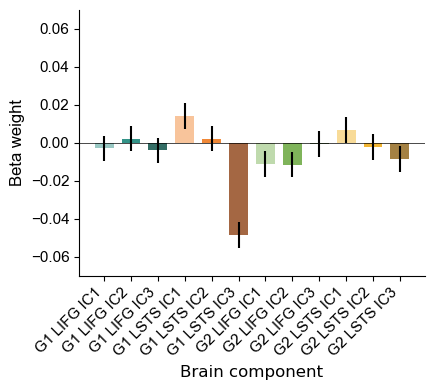

In [ ]:
b_df = pd.read_csv(os.path.join(workspace_path, "CONGRADS_rest", "lead_snps_all_betas.csv"), index_col=0)
in_df = b_df.loc[["rs35124509"], :]

fig, ax = plt.subplots(figsize=(17.8/4, 4))
plot_bars(df=in_df, eff_col='BETA', std_err_col='SE', sig_col='sig',
                  title='', y_label='Beta weight', ax=ax, color=color_list_comps, bar_w=0.7)

#switch of legend
ax.set_xlabel('Brain component', fontsize=12)
ax.set_ylabel('Beta weight', fontsize=12)
ax.set_ylim(-0.07, 0.07)

#change font size ticks and axis labels
xticks=["G1 LIFG IC1", "G1 LIFG IC2", "G1 LIFG IC3", "G1 LSTS IC1", "G1 LSTS IC2", "G1 LSTS IC3", "G2 LIFG IC1", "G2 LIFG IC2", "G2 LIFG IC3", "G2 LSTS IC1", "G2 LSTS IC2", "G2 LSTS IC3"]
ax.set_xticks(range(len(xticks)))
ax.set_xticklabels(xticks, rotation=45, ha='right')

for label in ax.get_xticklabels():
    label.set_fontsize(11)

for label in ax.get_yticklabels():
    label.set_fontsize(11)

plt.tight_layout()
plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "results", "Beta_EPHA3_rs35124509.png"), dpi=400)

C:\Users\jitame\AppData\Local\Temp\ipykernel_14852\1487825920.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)


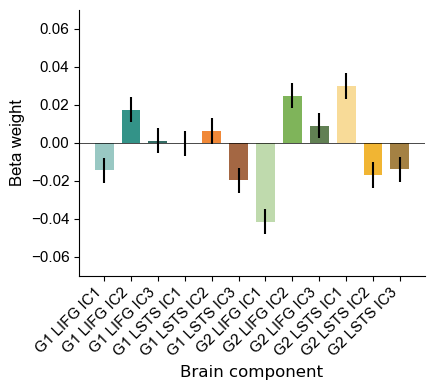

In [ ]:
#b_df = pd.read_csv(os.path.join(workspace_path, "CONGRADS_rest", "lead_snps_all_betas.csv"), index_col=0)
in_df = b_df.loc[["rs7080472"], :]

fig, ax = plt.subplots(figsize=(17.8/4, 4))
plot_bars(df=in_df, eff_col='BETA', std_err_col='SE', sig_col='sig',
                  title='', y_label='Beta weight', ax=ax, color=color_list_comps, bar_w=0.7)

#switch of legend
ax.set_xlabel('Brain component', fontsize=12)
ax.set_ylabel('Beta weight', fontsize=12)
ax.set_ylim(-0.07, 0.07)

#change font size ticks and axis labels
xticks=["G1 LIFG IC1", "G1 LIFG IC2", "G1 LIFG IC3", "G1 LSTS IC1", "G1 LSTS IC2", "G1 LSTS IC3", "G2 LIFG IC1", "G2 LIFG IC2", "G2 LIFG IC3", "G2 LSTS IC1", "G2 LSTS IC2", "G2 LSTS IC3"]
ax.set_xticks(range(len(xticks)))
ax.set_xticklabels(xticks, rotation=45, ha='right')

for label in ax.get_xticklabels():
    label.set_fontsize(11)

for label in ax.get_yticklabels():
    label.set_fontsize(11)

plt.tight_layout()
plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "results", "Beta_EPHA3_rs7080472.png"), dpi=400)

C:\Users\jitame\AppData\Local\Temp\ipykernel_14852\1487825920.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)


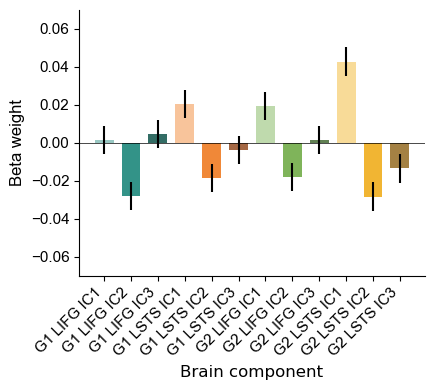

In [9]:
b_df = pd.read_csv(os.path.join(workspace_path, "CONGRADS_rest", "lead_snps_all_betas.csv"), index_col=0)
in_df = b_df.loc[["rs801597"], :]

fig, ax = plt.subplots(figsize=(17.8/4, 4))
plot_bars(df=in_df, eff_col='BETA', std_err_col='SE', sig_col='sig',
                  title='', y_label='Beta weight', ax=ax, color=color_list_comps, bar_w=0.7)

#switch of legend
ax.set_xlabel('Brain component', fontsize=12)
ax.set_ylabel('Beta weight', fontsize=12)
ax.set_ylim(-0.07, 0.07)

#change font size ticks and axis labels
xticks=["G1 LIFG IC1", "G1 LIFG IC2", "G1 LIFG IC3", "G1 LSTS IC1", "G1 LSTS IC2", "G1 LSTS IC3", "G2 LIFG IC1", "G2 LIFG IC2", "G2 LIFG IC3", "G2 LSTS IC1", "G2 LSTS IC2", "G2 LSTS IC3"]
ax.set_xticks(range(len(xticks)))
ax.set_xticklabels(xticks, rotation=45, ha='right')

for label in ax.get_xticklabels():
    label.set_fontsize(11)

for label in ax.get_yticklabels():
    label.set_fontsize(11)

plt.tight_layout()
plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "results", "Beta_EPHA3_rs801597.png"), dpi=400)

C:\Users\jitame\AppData\Local\Temp\ipykernel_15644\1487825920.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)


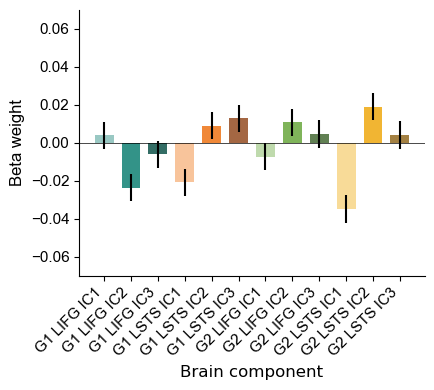

In [9]:
#b_df = pd.read_csv(os.path.join(workspace_path, "CONGRADS_rest", "lead_snps_all_betas_new.csv"), index_col=0)
in_df = b_df.loc[["rs6226"], :]

fig, ax = plt.subplots(figsize=(17.8/4, 4))
plot_bars(df=in_df, eff_col='BETA', std_err_col='SE', sig_col='sig',
                  title='', y_label='Beta weight', ax=ax, color=color_list_comps, bar_w=0.7)

#switch of legend
ax.set_xlabel('Brain component', fontsize=12)
ax.set_ylabel('Beta weight', fontsize=12)
ax.set_ylim(-0.07, 0.07)

#change font size ticks and axis labels
xticks=["G1 LIFG IC1", "G1 LIFG IC2", "G1 LIFG IC3", "G1 LSTS IC1", "G1 LSTS IC2", "G1 LSTS IC3", "G2 LIFG IC1", "G2 LIFG IC2", "G2 LIFG IC3", "G2 LSTS IC1", "G2 LSTS IC2", "G2 LSTS IC3"]
ax.set_xticks(range(len(xticks)))
ax.set_xticklabels(xticks, rotation=45, ha='right')

for label in ax.get_xticklabels():
    label.set_fontsize(11)

for label in ax.get_yticklabels():
    label.set_fontsize(11)

plt.tight_layout()
plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "results", "Beta_EPHA3_rs6226.png"), dpi=400)


C:\Users\jitame\AppData\Local\Temp\ipykernel_15644\1487825920.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=25, fontsize=9, ha='right', fontname=font)


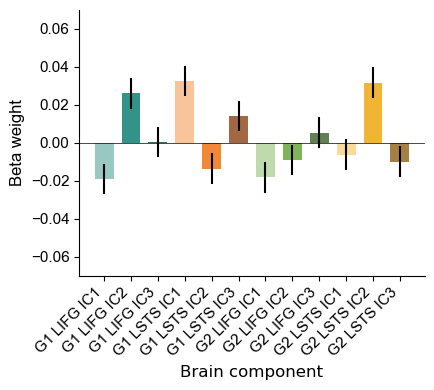

In [10]:


#b_df = pd.read_csv(os.path.join(workspace_path, "CONGRADS_rest", "lead_snps_all_betas_new.csv"), index_col=0)
in_df = b_df.loc[["rs56093896"], :]

fig, ax = plt.subplots(figsize=(17.8/4, 4))
plot_bars(df=in_df, eff_col='BETA', std_err_col='SE', sig_col='sig',
                  title='', y_label='Beta weight', ax=ax, color=color_list_comps, bar_w=0.7)

#switch of legend
ax.set_xlabel('Brain component', fontsize=12)
ax.set_ylabel('Beta weight', fontsize=12)
ax.set_ylim(-0.07, 0.07)

#change font size ticks and axis labels
xticks=["G1 LIFG IC1", "G1 LIFG IC2", "G1 LIFG IC3", "G1 LSTS IC1", "G1 LSTS IC2", "G1 LSTS IC3", "G2 LIFG IC1", "G2 LIFG IC2", "G2 LIFG IC3", "G2 LSTS IC1", "G2 LSTS IC2", "G2 LSTS IC3"]
ax.set_xticks(range(len(xticks)))
ax.set_xticklabels(xticks, rotation=45, ha='right')

for label in ax.get_xticklabels():
    label.set_fontsize(11)

for label in ax.get_yticklabels():
    label.set_fontsize(11)

plt.tight_layout()
plt.savefig(os.path.join(workspace_path, "CONGRADS_rest", "results", "Beta_EPHA3_rs56093896.png"), dpi=400)